In [17]:
import os
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import zipfile 
from pathlib import Path

import missingno as msno


In [18]:
zip_path = Path("C:\\Users\\chris\\Initiez_vous_au_ML_Ops\\Projet+Mise+en+prod+-+home-credit-default-risk.zip")
extract_dir = Path("data")

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

print("Extraction terminée !")

Extraction terminée !


In [19]:
pos_cash_balance = pd.read_csv(r"C:\Users\chris\Initiez_vous_au_ML_Ops\data\POS_CASH_balance.csv")
print('pos cash data shape: ', pos_cash_balance.shape)
pos_cash_balance.head()

pos cash data shape:  (10001358, 8)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


<Axes: >

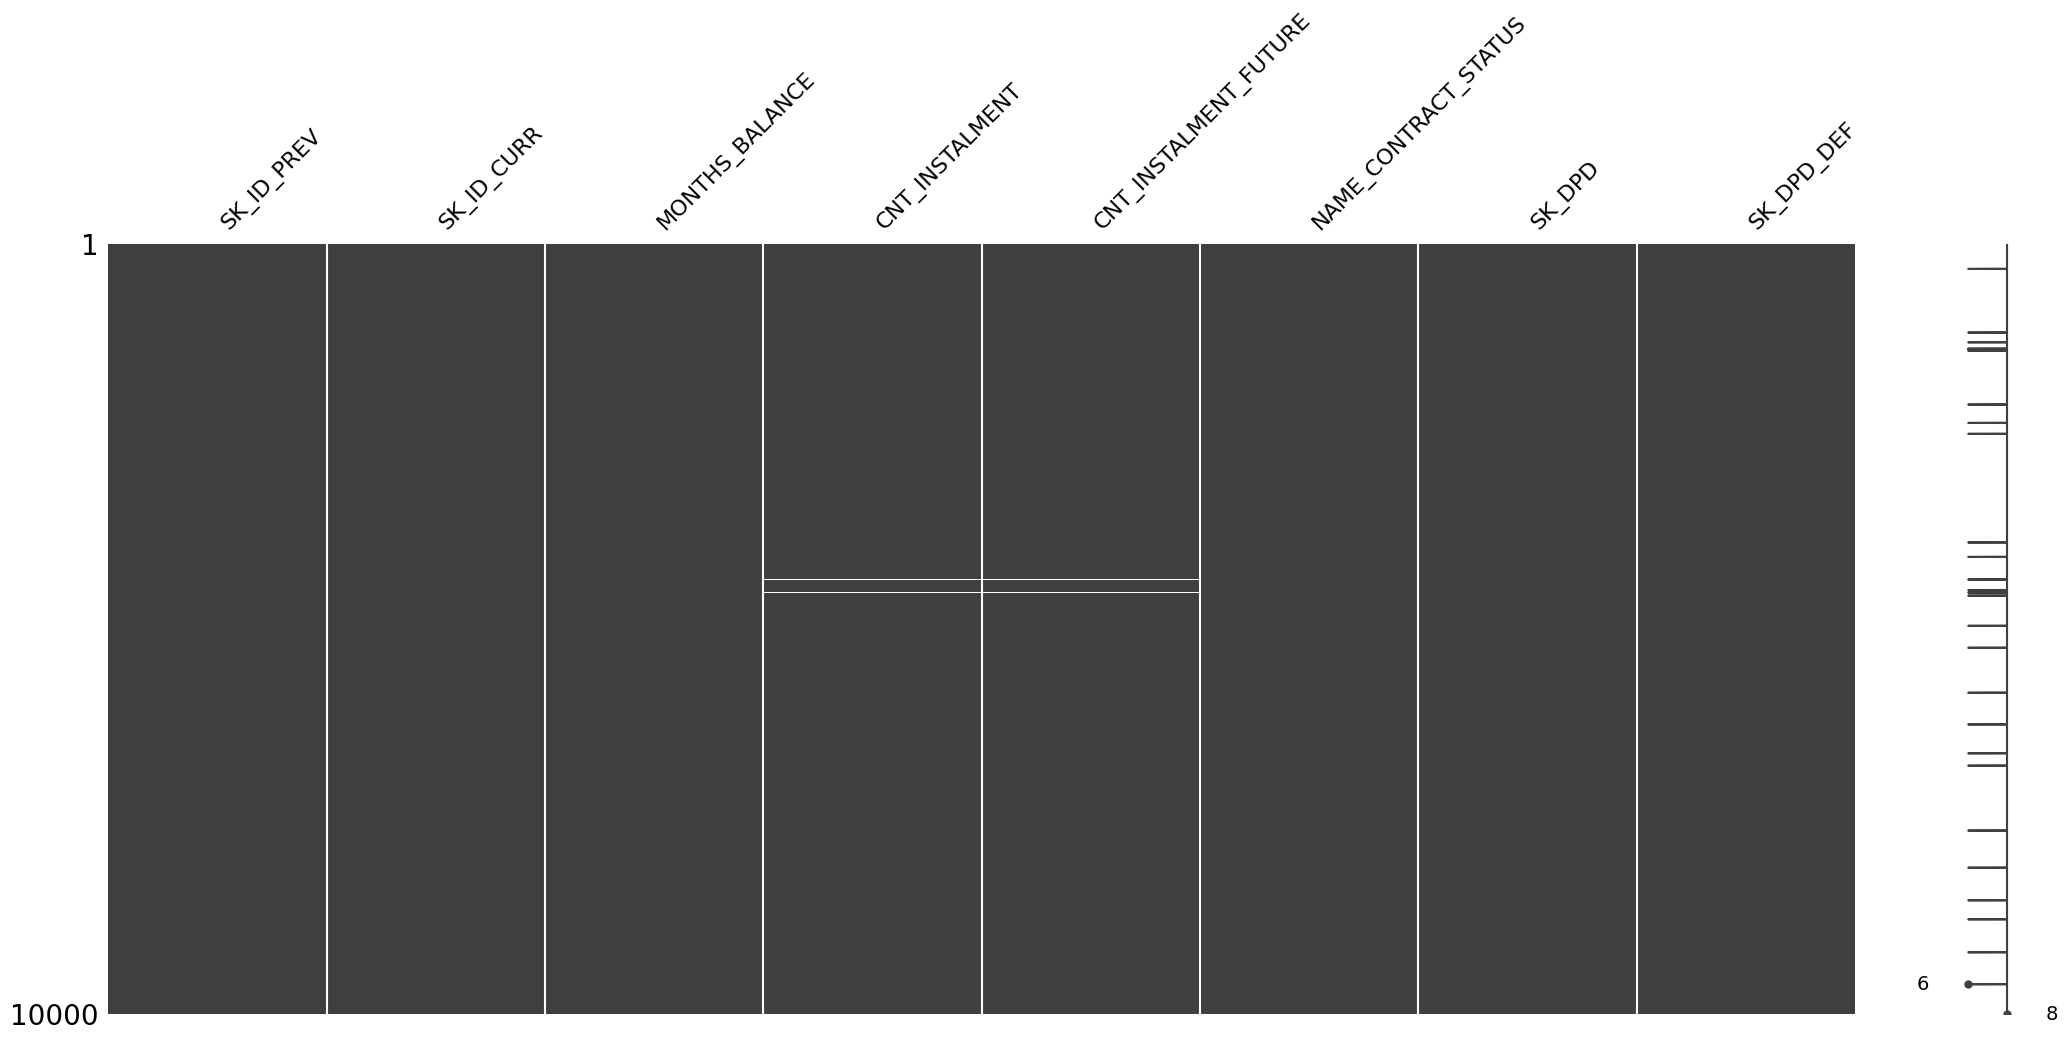

In [20]:
%matplotlib inline
msno.matrix(pos_cash_balance.sample(10000))

In [21]:
pos_cash_balance.duplicated().sum()

np.int64(0)

In [22]:
pos_cash_balance.isnull().sum()

SK_ID_PREV                   0
SK_ID_CURR                   0
MONTHS_BALANCE               0
CNT_INSTALMENT           26071
CNT_INSTALMENT_FUTURE    26087
NAME_CONTRACT_STATUS         0
SK_DPD                       0
SK_DPD_DEF                   0
dtype: int64

In [23]:
valeurs_manquantes = (pos_cash_balance.isnull().sum() / len(pos_cash_balance)) * 100
print(valeurs_manquantes)

SK_ID_PREV               0.000000
SK_ID_CURR               0.000000
MONTHS_BALANCE           0.000000
CNT_INSTALMENT           0.260675
CNT_INSTALMENT_FUTURE    0.260835
NAME_CONTRACT_STATUS     0.000000
SK_DPD                   0.000000
SK_DPD_DEF               0.000000
dtype: float64


In [24]:
pos_cash_balance.describe()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,SK_DPD,SK_DPD_DEF
count,1.000136e+07,1.000136e+07,1.000136e+07,9.975287e+06,9.975271e+06,1.000136e+07,1.000136e+07
mean,1.903217e+06,2.784039e+05,-3.501259e+01,1.708965e+01,1.048384e+01,1.160693e+01,6.544684e-01
std,5.358465e+05,1.027637e+05,2.606657e+01,1.199506e+01,1.110906e+01,1.327140e+02,3.276249e+01
min,1.000001e+06,1.000010e+05,-9.600000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.434405e+06,1.895500e+05,-5.400000e+01,1.000000e+01,3.000000e+00,0.000000e+00,0.000000e+00
50%,1.896565e+06,2.786540e+05,-2.800000e+01,1.200000e+01,7.000000e+00,0.000000e+00,0.000000e+00
75%,2.368963e+06,3.674290e+05,-1.300000e+01,2.400000e+01,1.400000e+01,0.000000e+00,0.000000e+00
max,2.843499e+06,4.562550e+05,-1.000000e+00,9.200000e+01,8.500000e+01,4.231000e+03,3.595000e+03


In [25]:
pos_cash_balance['NAME_CONTRACT_STATUS'].value_counts();

In [26]:
# Historique
pos_cash_balance['MONTHS_BALANCE'].value_counts();

In [27]:
# Nombre d’échéances prévues
pos_cash_balance['CNT_INSTALMENT'].value_counts();

In [28]:
# Nombre d’échéances restantes
pos_cash_balance['CNT_INSTALMENT_FUTURE'].value_counts();

In [29]:
# SK_DPD: Days past due. The number of days that the payment of the installment was overdue: 
# The value 0 means that the payment was made on time, while a positive value indicates the number of days the payment was late.
pos_cash_balance['SK_DPD'].value_counts();

In [30]:
# SK_DPD_DEF: Days past due with penalty:
# tracks the number of days that a payment was overdue and has incurred a penalty or fine as a result. 
# A value of 0 indicates that the payment was made on time without any penalties, 
# while a positive value indicates the number of days the payment was late and has resulted in a penalty.
pos_cash_balance['SK_DPD_DEF'].value_counts();

In [31]:
# encodage
pos_cash = pd.get_dummies(
    pos_cash_balance, 
    columns=['NAME_CONTRACT_STATUS'], 
    prefix='STATUS',
    drop_first=True
)

In [36]:
print(pos_cash.columns)

Index(['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT',
       'CNT_INSTALMENT_FUTURE', 'SK_DPD', 'SK_DPD_DEF',
       'STATUS_Amortized debt', 'STATUS_Approved', 'STATUS_Canceled',
       'STATUS_Completed', 'STATUS_Demand', 'STATUS_Returned to the store',
       'STATUS_Signed', 'STATUS_XNA'],
      dtype='object')


In [37]:
# Agrégation DIRECTE par client (SK_ID_CURR)
# Ceci agrège TOUS les snapshots mensuels de TOUS les contrats POS du client
pos_agg = pos_cash.groupby('SK_ID_CURR').agg({
    'MONTHS_BALANCE': ['min', 'max', 'size'],  # ancienneté et nombre de snapshots
    'CNT_INSTALMENT': ['mean', 'max', 'sum'],
    'CNT_INSTALMENT_FUTURE': ['mean', 'min', 'sum'],
    'SK_DPD': ['mean', 'max', 'sum'],  #   important pour le risque !
    'SK_DPD_DEF': ['mean', 'max', 'sum'],  # Jours de retard définis
    
    # Pour les colonnes OneHot, sum indique le nombre de mois dans ce statut
    'STATUS_Amortized debt': 'sum',
    'STATUS_Completed': 'sum',
    'STATUS_Demand': 'sum',
    'STATUS_Returned to the store': 'sum',
    'STATUS_Signed': 'sum',
    'STATUS_XNA': 'sum',
})

pos_agg.columns = ['POS_' + '_'.join(col).upper() for col in pos_agg.columns]
pos_agg.reset_index(inplace=True)



In [39]:
# Ratio de retards (feature)
pos_agg['POS_DPD_RATIO'] = pos_agg['POS_SK_DPD_SUM'] / (pos_agg['POS_MONTHS_BALANCE_SIZE'] + 1)

pos_agg.columns

Index(['SK_ID_CURR', 'POS_MONTHS_BALANCE_MIN', 'POS_MONTHS_BALANCE_MAX',
       'POS_MONTHS_BALANCE_SIZE', 'POS_CNT_INSTALMENT_MEAN',
       'POS_CNT_INSTALMENT_MAX', 'POS_CNT_INSTALMENT_SUM',
       'POS_CNT_INSTALMENT_FUTURE_MEAN', 'POS_CNT_INSTALMENT_FUTURE_MIN',
       'POS_CNT_INSTALMENT_FUTURE_SUM', 'POS_SK_DPD_MEAN', 'POS_SK_DPD_MAX',
       'POS_SK_DPD_SUM', 'POS_SK_DPD_DEF_MEAN', 'POS_SK_DPD_DEF_MAX',
       'POS_SK_DPD_DEF_SUM', 'POS_STATUS_AMORTIZED DEBT_SUM',
       'POS_STATUS_COMPLETED_SUM', 'POS_STATUS_DEMAND_SUM',
       'POS_STATUS_RETURNED TO THE STORE_SUM', 'POS_STATUS_SIGNED_SUM',
       'POS_STATUS_XNA_SUM', 'POS_DPD_RATIO'],
      dtype='object')

In [ ]:
# N.B: Merger au niveau CLIENT dans application_train
# train = application_train.merge(pos_agg, on='SK_ID_CURR', how='left')